# The first CHEG231 Juypter notebook

The goal of this notebook is to calcuate the molar volume of a gas using the van der Waals (vdw) equation of state.

$$ (P + a/\underline{V}^2)(\underline{V}-b) = RT$$

$$ f(V) = RT - (P +a/\underline{V}^2)(\underline{V}-b) $$

Here, $ \underline{V} $ is the molar volume (m^3/mol).

In [13]:
import scipy.optimize as opt

"""
Constants for the vdW equation for CO2
"""

a = 0.3658    # Pa m^6/mol^2
b = 4.286e-5  # m^3/mol

"""
Other parameters
"""

R = 8.314   # J/mol.K  R = the ideal gas constant

P = 5e4     # Pa, pressure
T = 300     # K, temperature

def vdW(V):
    x = R*T - (P + a/V**2)*(V-b)
    return x

V_vdw = opt.fsolve(vdW, R*T/P)

print(V_vdw)
# has units of mol/m3

[0.04978002]


We are going to compare the vdW volume to the one predicted by the ideal gas

$$ P\underline{V} = RT$$

In [14]:
V_ideal = R*T/P
print(V_ideal)
print((V_vdw-V_ideal)/V_ideal)

0.049884
[-0.00208444]


---
# Additional calculations for the homework:

1. What is the molar volume of CO2 for 150K, 200K, 250K, and 350K calculated using the van der Waals equation?
2. Make a plot of the molar volume of CO2 using the van der Waals equation between 150K and 350K

In [15]:
# First, we'll need numpy

import numpy as np

# then make an array of temperatures

T = np.array([150, 200, 250, 300, 350])

# and caculate (now an array) of molar volumes

V_ideal = R*T/P
V_vdw = opt.fsolve(vdW, R*T/P)

print(V_vdw)
print(V_ideal)
print((V_vdw-V_ideal)/V_ideal)

[0.02468905 0.03307797 0.04143648 0.04978002 0.05811506]
[0.024942 0.033256 0.04157  0.049884 0.058198]
[-0.01014158 -0.00535325 -0.00321185 -0.00208444 -0.00142505]


We can make a table of the results:

In [16]:
# Transpose and stack the arrays

# First I have to reshape the array into a 1x5 array:
T = T.reshape(1,5)
V_vdw = V_vdw.reshape(1,5)
V_ideal = V_ideal.reshape(1,5)

# I'll also include the differences
V_diff = (V_vdw-V_ideal)/V_ideal
V_diff = V_diff.reshape(1,5)

# Now we're ready to transpose the array
table = np.hstack((T.T, V_vdw.T, V_ideal.T, V_diff.T))

# and print the table
print(table)

[[ 1.50000000e+02  2.46890487e-02  2.49420000e-02 -1.01415803e-02]
 [ 2.00000000e+02  3.30779722e-02  3.32560000e-02 -5.35325351e-03]
 [ 2.50000000e+02  4.14364832e-02  4.15700000e-02 -3.21185374e-03]
 [ 3.00000000e+02  4.97800199e-02  4.98840000e-02 -2.08443705e-03]
 [ 3.50000000e+02  5.81150647e-02  5.81980000e-02 -1.42505485e-03]]


What would happen if we printed the table without transposed arrays?

In [17]:
print(T, V_vdw, V_ideal, V_diff)
print()
print(np.hstack((T, V_vdw, V_ideal, V_diff)))

[[150 200 250 300 350]] [[0.02468905 0.03307797 0.04143648 0.04978002 0.05811506]] [[0.024942 0.033256 0.04157  0.049884 0.058198]] [[-0.01014158 -0.00535325 -0.00321185 -0.00208444 -0.00142505]]

[[ 1.50000000e+02  2.00000000e+02  2.50000000e+02  3.00000000e+02
   3.50000000e+02  2.46890487e-02  3.30779722e-02  4.14364832e-02
   4.97800199e-02  5.81150647e-02  2.49420000e-02  3.32560000e-02
   4.15700000e-02  4.98840000e-02  5.81980000e-02 -1.01415803e-02
  -5.35325351e-03 -3.21185374e-03 -2.08443705e-03 -1.42505485e-03]]


This makes one long row array!

Next, we'll make a plot.

In [18]:
# Make many more points for T

T = np.arange(150, 450, 1)

# Recalculate V_vdw and V_ideal for those points

V_vdw = opt.fsolve(vdW, R*T/P)
V_ideal = R*T/P


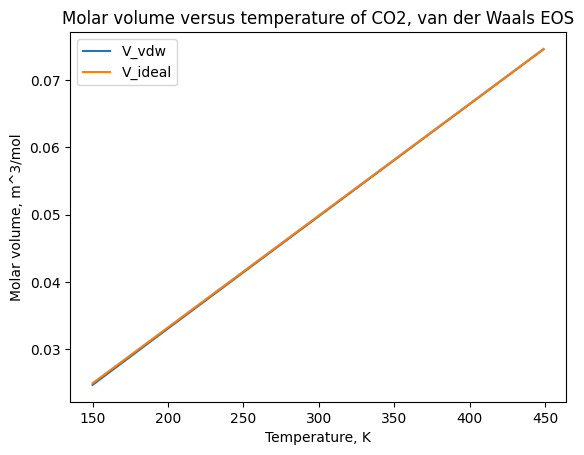

In [19]:
# Create a figure. We need to load matplotlib

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
plt.title('Molar volume versus temperature of CO2, van der Waals EOS')
ax.plot(T,V_vdw, label='V_vdw')
ax.plot(T,V_ideal, label='V_ideal')
ax.set(xlabel='Temperature, K',ylabel='Molar volume, m^3/mol')
ax.legend(loc='best')
#plt.show()

Let's plot the difference between the vdw and ideal equations of state?

[Text(0.5, 0, 'Temperature, K'), Text(0, 0.5, 'Molar volume, m^3/mol')]

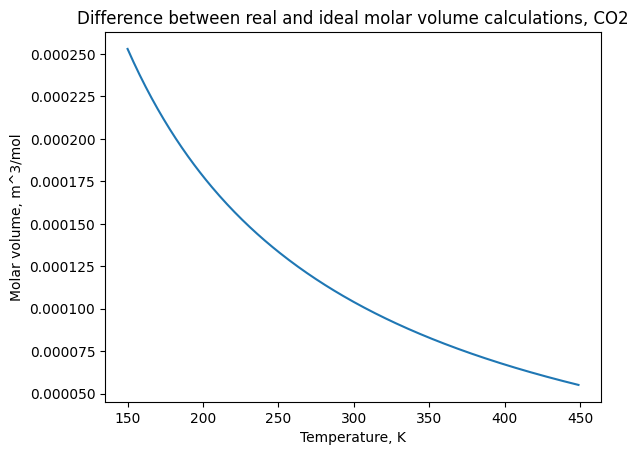

In [20]:
fig, ax = plt.subplots()
plt.title('Difference between real and ideal molar volume calculations, CO2')
ax.plot(T,V_ideal-V_vdw)
ax.set(xlabel='Temperature, K',ylabel='Molar volume, m^3/mol')
#ax.legend(loc='best')
#plt.show()

The molar volume of the van der Waals EOS is lower than the ideal gas volume. As a percentage,

[Text(0.5, 0, 'Temperature, K'), Text(0, 0.5, 'Molar volume, m^3/mol')]

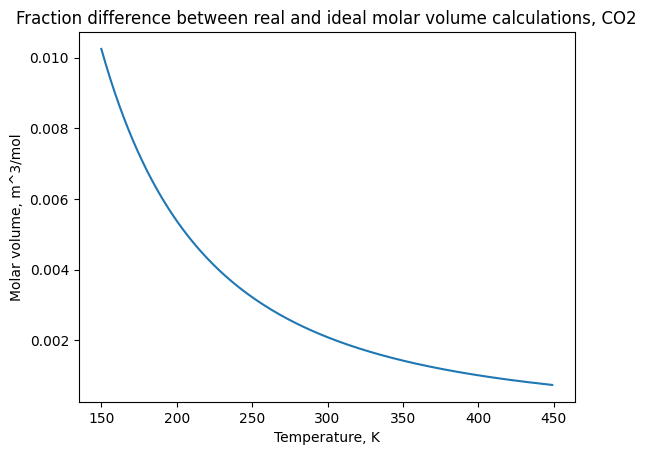

In [21]:
fig, ax = plt.subplots()
plt.title('Fraction difference between real and ideal molar volume calculations, CO2')
ax.plot(T,(V_ideal-V_vdw)/V_vdw)
ax.set(xlabel='Temperature, K',ylabel='Molar volume, m^3/mol')
#ax.legend(loc='best')
#plt.show()

As the temperature increases from 150K to 450K, the difference between the real and ideal properties changes from over 10% to less than 1%. The fluid becomes more ideal as the temeprature increases (at this pressure).